# Power Breakers

**Name(s)**: 
Alex Twoy <atwoy@ucsd.edu> - A17580384
Mitchell Farrington <mfarring@ucsd.edu>  - A15378625
Anuradha Jaganathan <ajaganathan@ucsd.edu> - A69038119
Kyle Packer <kpacker@ucsd.edu> - A69036932

**Website Link**: (your website link)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path


import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc259r_utils import * # Feel free to uncomment and use this.

## Step 1: Introduction

**Questions**: 
1. Which area suffered the most power outages and why?
2. What was the average length of the power outages?
3. Does the type of area (urban vs. rural) play a huge role in determining how often power outages occur?


## Step 2: Data Cleaning and Exploratory Data Analysis

In [2]:
#install required packages
import sys                                                                                                            
!uv pip install openpyxl  
!uv pip install jupyterlab plotly

/bin/bash: line 1: uv: command not found
/bin/bash: line 1: uv: command not found


### Loading the dataset

In [3]:
outage_url = 'https://engineering.purdue.edu/LASCI/research-data/outages/outage.xlsx'
df = pd.read_excel(outage_url, skiprows=list(range(5))+[6], index_col = 'OBS') #excluding the first 5 lines since they are comments on the dataset and the metric units line after the header
df.head()
df.columns

Index(['variables', 'YEAR', 'MONTH', 'U.S._STATE', 'POSTAL.CODE',
       'NERC.REGION', 'CLIMATE.REGION', 'ANOMALY.LEVEL', 'CLIMATE.CATEGORY',
       'OUTAGE.START.DATE', 'OUTAGE.START.TIME', 'OUTAGE.RESTORATION.DATE',
       'OUTAGE.RESTORATION.TIME', 'CAUSE.CATEGORY', 'CAUSE.CATEGORY.DETAIL',
       'HURRICANE.NAMES', 'OUTAGE.DURATION', 'DEMAND.LOSS.MW',
       'CUSTOMERS.AFFECTED', 'RES.PRICE', 'COM.PRICE', 'IND.PRICE',
       'TOTAL.PRICE', 'RES.SALES', 'COM.SALES', 'IND.SALES', 'TOTAL.SALES',
       'RES.PERCEN', 'COM.PERCEN', 'IND.PERCEN', 'RES.CUSTOMERS',
       'COM.CUSTOMERS', 'IND.CUSTOMERS', 'TOTAL.CUSTOMERS', 'RES.CUST.PCT',
       'COM.CUST.PCT', 'IND.CUST.PCT', 'PC.REALGSP.STATE', 'PC.REALGSP.USA',
       'PC.REALGSP.REL', 'PC.REALGSP.CHANGE', 'UTIL.REALGSP', 'TOTAL.REALGSP',
       'UTIL.CONTRI', 'PI.UTIL.OFUSA', 'POPULATION', 'POPPCT_URBAN',
       'POPPCT_UC', 'POPDEN_URBAN', 'POPDEN_UC', 'POPDEN_RURAL',
       'AREAPCT_URBAN', 'AREAPCT_UC', 'PCT_LAND', 'PCT_WATER_TOT'

In [4]:
#Review the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1534 entries, 1 to 1534
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   variables                0 non-null      float64       
 1   YEAR                     1534 non-null   int64         
 2   MONTH                    1525 non-null   float64       
 3   U.S._STATE               1534 non-null   object        
 4   POSTAL.CODE              1534 non-null   object        
 5   NERC.REGION              1534 non-null   object        
 6   CLIMATE.REGION           1528 non-null   object        
 7   ANOMALY.LEVEL            1525 non-null   float64       
 8   CLIMATE.CATEGORY         1525 non-null   object        
 9   OUTAGE.START.DATE        1525 non-null   datetime64[ns]
 10  OUTAGE.START.TIME        1525 non-null   object        
 11  OUTAGE.RESTORATION.DATE  1476 non-null   datetime64[ns]
 12  OUTAGE.RESTORATION.TIME  1476 non-null 

### Clean Data

In [5]:
#Copy of the original dataframe for analysis
outage_df = df.copy()

#Based on the data variable descriptions in https://www.sciencedirect.com/science/article/pii/S2352340918307182?via%3Dihub, 
#dropping unwanted columsn like variables(all null), unit price , total sales for electricity,  GSP and Utility contribution

outage_df = outage_df.drop(columns=['variables', 'RES.PRICE','COM.PRICE', 'IND.PRICE','TOTAL.PRICE', 
                                    'RES.PRICE','RES.SALES', 'COM.SALES','IND.SALES', 'TOTAL.SALES','PC.REALGSP.STATE', 'PC.REALGSP.USA','PC.REALGSP.REL', 'PC.REALGSP.CHANGE','UTIL.REALGSP', 'TOTAL.REALGSP','UTIL.CONTRI', 'PI.UTIL.OFUSA'])

#Replace . with _ for clean variable names
outage_df.columns = outage_df.columns.str.replace('.', '_', regex=False)                                              

outage_df = outage_df.iloc[1:].reset_index(drop=True)

#Renameing the required columns for ease of use and consistency
outage_df = outage_df.rename(columns={'U_S__STATE': 'US_STATE', 'POSTAL_CODE': 'STATE_CODE', 'OUTAGE_START_DATE(Day of the week, Month Day, Year)':'OUTAGE_START_DATE',
                                        'OUTAGE_START_TIME(Hour:Minute:Second (AM / PM))': 'OUTAGE_START_TIME', 'OUTAGE_RESTORATION_DATE(Day of the week, Month Day, Year)': 'OUTAGE_RESTORATION_DATE',
                                        'OUTAGE_RESTORATION_TIME(Hour:Minute:Second (AM / PM))':'OUTAGE_RESTORATION_TIME', 'POPDEN_URBAN(persons per square mile)':'POP_DENSITY_URBAN',
                                        'POPDEN_UC(persons per square mile)':'POP_DENSITY_UC','POPDEN_RURAL(persons per square mile)':'POP_DENSITY_RURAL',
                                        'OUTAGE_RESTORATION_TIME(Hour:Minute:Second (AM / PM))':'OUTAGE_RESTORATION_TIME','RES_PERCEN':'RES_PERCENT','COM_PERCEN':'COM_PERCENT','IND_PERCEN':'IND_PERCENT',
                                        'RES_CUST_PCT':'RES_CUST_PERCENT','COM_CUST_PCT':'COM_CUST_PERCENT','IND_CUST_PCT':'IND_CUST_PERCENT','PCT_LAND':'LAND_AREA_PERCENT','PCT_WATER_TOT':'TOTAL_WATER_AREA_PERCENT',
                                        'PCT_WATER_INLAND': 'INLAND_WATER_AREA_PERCENT','AREAPCT_URBAN':'URBAN_AREA_PERCENT','AREAPCT_UC':'UC_AREA_PERCENT','OUTAGE_DURATION':'OUTAGE_DURATION_MINS'
                                     }) 

#Merging the date and time fields for analysis
outage_df['OUTAGE_START_TIMESTAMP'] = pd.to_datetime(                                                                 
      outage_df['OUTAGE_START_DATE'].astype(str) + ' ' + outage_df['OUTAGE_START_TIME'].astype(str),
      format='%Y-%m-%d %H:%M:%S',                                                                                       
      errors='coerce'
  )

outage_df['OUTAGE_RESTORATION_TIMESTAMP'] = pd.to_datetime(                                                                 
      outage_df['OUTAGE_RESTORATION_DATE'].astype(str) + ' ' + outage_df['OUTAGE_RESTORATION_TIME'].astype(str),
      format='%Y-%m-%d %H:%M:%S',                                                                                       
      errors='coerce'
  )

outage_df = outage_df.drop(columns=['OUTAGE_START_DATE','OUTAGE_START_TIME','OUTAGE_RESTORATION_DATE','OUTAGE_RESTORATION_TIME'])

#Converting fields with interger data from object data type
intcols = ['MONTH','OUTAGE_DURATION_MINS','CUSTOMERS_AFFECTED','DEMAND_LOSS_MW','POPULATION']
outage_df[intcols] = outage_df[intcols].apply(pd.to_numeric, errors='coerce').astype('Int64')

#Outage duration is a required field to help answer questions on power outage. Hence dropping records with NULL/NaN outage duration only
outage_df = outage_df.dropna(subset=['OUTAGE_DURATION_MINS'])     

outage_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475 entries, 0 to 1531
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEAR                          1475 non-null   int64         
 1   MONTH                         1475 non-null   Int64         
 2   US_STATE                      1475 non-null   object        
 3   STATE_CODE                    1475 non-null   object        
 4   NERC_REGION                   1475 non-null   object        
 5   CLIMATE_REGION                1470 non-null   object        
 6   ANOMALY_LEVEL                 1475 non-null   float64       
 7   CLIMATE_CATEGORY              1475 non-null   object        
 8   CAUSE_CATEGORY                1475 non-null   object        
 9   CAUSE_CATEGORY_DETAIL         1028 non-null   object        
 10  HURRICANE_NAMES               71 non-null     object        
 11  OUTAGE_DURATION_MINS          1475 

In [6]:
outage_df.loc[outage_df['OUTAGE_DURATION_MINS'].isnull(), 'US_STATE'].nunique()

0

In [7]:
#Review the data in all fields for further data cleansing
display_df(outage_df.sort_values('OUTAGE_START_TIMESTAMP'),
           rows=5,
           cols=37)

,YEAR,MONTH,US_STATE,STATE_CODE,NERC_REGION,CLIMATE_REGION,ANOMALY_LEVEL,CLIMATE_CATEGORY,CAUSE_CATEGORY,CAUSE_CATEGORY_DETAIL,HURRICANE_NAMES,OUTAGE_DURATION_MINS,DEMAND_LOSS_MW,CUSTOMERS_AFFECTED,RES_PERCENT,COM_PERCENT,IND_PERCENT,RES_CUSTOMERS,COM_CUSTOMERS,IND_CUSTOMERS,TOTAL_CUSTOMERS,RES_CUST_PERCENT,COM_CUST_PERCENT,IND_CUST_PERCENT,POPULATION,POPPCT_URBAN,POPPCT_UC,POPDEN_URBAN,POPDEN_UC,POPDEN_RURAL,URBAN_AREA_PERCENT,UC_AREA_PERCENT,LAND_AREA_PERCENT,TOTAL_WATER_AREA_PERCENT,INLAND_WATER_AREA_PERCENT,OUTAGE_START_TIMESTAMP,OUTAGE_RESTORATION_TIMESTAMP
809,2000,1,South Carolina,SC,SERC,Southeast,-1.6,cold,severe weather,winter storm,NaN,7440,450,133000,36.45,20.5,41.89,1764298,274003,5077,2059496,85.67,13.30,0.25,4024223,66.33,10.55,1288.1,1117.1,56.3,7.92,1.45,93.88,6.12,3.32,2000-01-23 08:00:00,2000-01-28 12:00:00
811,2000,1,South Carolina,SC,SERC,Southeast,-1.6,cold,severe weather,winter storm,NaN,6600,300,81000,36.45,20.5,41.89,1764298,274003,5077,2059496,85.67,13.30,0.25,4024223,66.33,10.55,1288.1,1117.1,56.3,7.92,1.45,93.88,6.12,3.32,2000-01-29 22:00:00,2000-02-03 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,2016,7,Delaware,DE,RFC,Northeast,-0.3,normal,intentional attack,NaN,NaN,507,0,0,NaN,NaN,NaN,419234,53366,873,473473,88.54,11.27,0.18,952698,83.30,14.59,1838.3,1083.0,97.3,20.88,6.21,78.30,21.70,3.66,2016-07-21 06:18:00,2016-07-21 14:45:00
604,2016,7,Pennsylvania,PA,RFC,Northeast,-0.3,normal,system operability disruption,voltage reduction,NaN,278,87,<NA>,NaN,NaN,NaN,5335555,696080,23372,6055013,88.12,11.50,0.39,12787085,78.66,7.98,2123.4,1528.6,67.7,10.52,1.48,97.15,2.85,1.22,2016-07-23 15:15:00,2016-07-23 19:53:00


In [8]:
#Review the metrics descrition for outdage durtation
display_df(outage_df['OUTAGE_DURATION_MINS'].describe(),
          rows=10)

count      1475.0
mean       2625.1
std       5944.49
min           0.0
25%         101.5
50%         697.0
75%        2880.0
max      108653.0
Name: OUTAGE_DURATION_MINS, dtype: Float64

### Univariate Analysis

In [9]:
#Distibution of outage duration 
outage_dist_fig = px.histogram(outage_df, x="OUTAGE_DURATION_MINS", nbins=10,
                     title="Distribution of Outage Duration",
                     labels={"OUTAGE_DURATION_MINS": "Duration (mins)"})
outage_dist_fig.show(renderer='iframe')

#Most of the outage duration are withing 20K mins, with 75% being 2880. Keeping the data between Q1 and Q3 quartile. 
outage_df_q1q3 = outage_df[outage_df['OUTAGE_DURATION_MINS'] <= 2880].reset_index()

outage_dist_fig = px.histogram(outage_df_q1q3, x="OUTAGE_DURATION_MINS", nbins=10,
                     title="Distribution of Outage Duration below 2880 Mins",
                     labels={"OUTAGE_DURATION_MINS": "Duration (mins)"})
outage_dist_fig.show(renderer='iframe')

### Bivariate analysis

In [10]:
#US States with most outages
states_most_outage = outage_df_q1q3['STATE_CODE'].value_counts().reset_index()
states_most_outage.columns = ['state', 'outage_count']
outage_state_most_fig = px.choropleth(states_most_outage,                                                                                       
                      locations='state',
                      locationmode='USA-states',
                      color='outage_count',
                      scope='usa',
                      color_continuous_scale='Blues',
                      title='Number of Outages by State')
outage_state_most_fig.show(renderer='iframe')

In [11]:
#US States with longest outage
states_longest_outage = outage_df_q1q3.groupby('STATE_CODE')['OUTAGE_DURATION_MINS'].sum().reset_index()
states_longest_outage.columns = ['state', 'total_mins']
#display_df(states_longest_outage.sort_values(ascending=False),rows=50)
outage_state_longest_fig = px.choropleth(states_longest_outage,                                                                                       
                      locations='state',                      
                      locationmode='USA-states',
                      color='total_mins',
                      scope='usa',
                      color_continuous_scale='Reds',
                      title='Longest Outage Durations by State')
outage_state_longest_fig.show(renderer='iframe')


In [12]:
# Filter to outages whose CAUSE_CATEGORY is exactly "severe weather"
outage_df_severe = outage_df[outage_df["CAUSE_CATEGORY"] == "severe weather"].copy()

# Count severe-weather outages by state
states_most_outage = (
    outage_df_severe["STATE_CODE"]
    .value_counts()
    .reset_index(name="outage_count")
    .rename(columns={"index": "STATE_CODE"})
)

# Choropleth
outage_state_most_fig = px.choropleth(
    states_most_outage,
    locations="STATE_CODE",
    locationmode="USA-states",
    color="outage_count",
    scope="usa",
    color_continuous_scale="Blues",
    title="Severe-Weather Outages by State",
)

# Make borders and background clearer
outage_state_most_fig.update_traces(marker_line_color="white", marker_line_width=0.6)
outage_state_most_fig.update_geos(
    showcountries=False,
    showcoastlines=True,
    coastlinecolor="black",
    showland=True,
    landcolor="rgb(240, 240, 240)",
    fitbounds="locations",
)
outage_state_most_fig.update_layout(
    margin=dict(l=0, r=0, t=60, b=0),
    paper_bgcolor="white",
    geo_bgcolor="white",
)

outage_state_most_fig.show(renderer="iframe")  

In [13]:
# Filter to severe-weather outages
outage_df_severe = outage_df[outage_df["CAUSE_CATEGORY"] == "severe weather"].copy()

if outage_df_severe.empty:
    raise ValueError("No rows with CAUSE_CATEGORY == 'severe weather'.")

# Average outage duration (minutes) by state
state_duration = (
    outage_df_severe.groupby("STATE_CODE", as_index=False)["OUTAGE_DURATION_MINS"]
    .mean()
    .rename(columns={"OUTAGE_DURATION_MINS": "avg_outage_duration_mins"})
)

avg_duration_fig = px.choropleth(
    state_duration,
    locations="STATE_CODE",
    locationmode="USA-states",
    color="avg_outage_duration_mins",
    scope="usa",
    color_continuous_scale="Reds",
    title="Average Severe-Weather Outage Duration (mins) by State",
    labels={"avg_outage_duration_mins": "Avg outage (mins)"},
)

avg_duration_fig.update_traces(marker_line_color="white", marker_line_width=0.6)
avg_duration_fig.update_geos(
    showcountries=False,
    showcoastlines=True,
    coastlinecolor="black",
    showland=True,
    landcolor="rgb(240, 240, 240)",
    fitbounds="locations",
)
avg_duration_fig.update_layout(
    margin=dict(l=0, r=0, t=60, b=0),
    paper_bgcolor="white",
    geo_bgcolor="white",
)

avg_duration_fig.show(renderer="iframe")

In [14]:
#Outages by Climate Category 
outage_climate_fig = px.box(outage_df_q1q3, x='CLIMATE_CATEGORY', y='OUTAGE_DURATION_MINS',
                     title='Outage Duration by Climate Category (< 3000 mins)')
outage_climate_fig.show(renderer='iframe')
#Outage is up during Warm and Cole months

#Outages by Cause 
outage_cause_fig = px.box(outage_df_q1q3, x='CAUSE_CATEGORY', y='OUTAGE_DURATION_MINS',
                   title='Outage Duration by Cause (< 3000 mins)')
outage_cause_fig.show(renderer='iframe')
#Outages are up during severe Weather, fuel supply emergency, public appeal and equipment failure. Longest duration outliers are during intentional attack

In [15]:
#Outage by Region and Cause 
outage_region_cause = outage_df.groupby(['CLIMATE_REGION','CAUSE_CATEGORY'])['OUTAGE_DURATION_MINS'].sum().reset_index()                                                        
   
outage_region_cause_fig = px.bar(outage_region_cause,
                            x='CLIMATE_REGION',                                                                                      
                            y='OUTAGE_DURATION_MINS',                                                                                
                            color='CAUSE_CATEGORY',
                            title='Outage Duration by Region and Cause',
                            labels={'OUTAGE_DURATION_MINS': 'Total Duration (mins)',
                                   'CLIMATE_REGION': 'Region'})
outage_region_cause_fig.show(renderer='iframe')

### Correlation Analysis

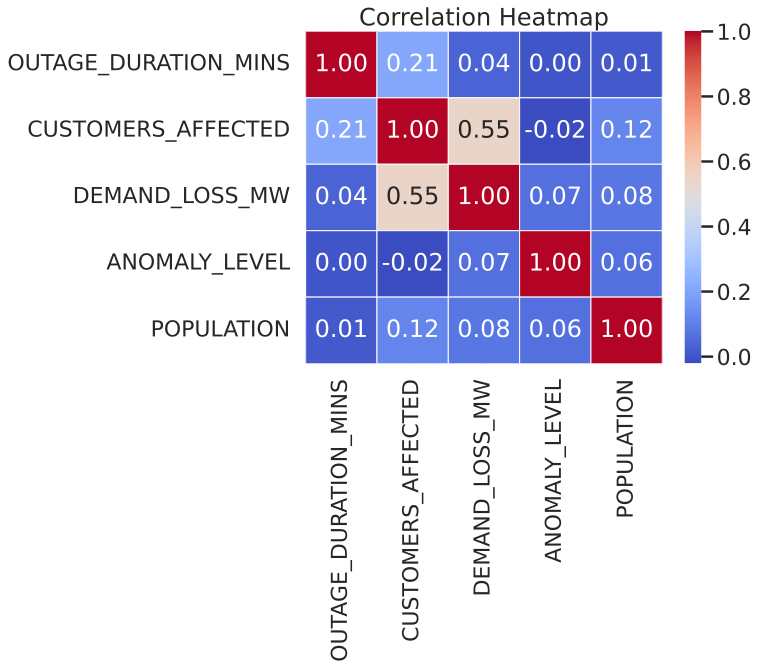

In [16]:
corr_cols = ['OUTAGE_DURATION_MINS','CUSTOMERS_AFFECTED','DEMAND_LOSS_MW',
               'ANOMALY_LEVEL','POPULATION']
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(outage_df_q1q3[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Heatmap')
plt.show()

#No or weak correlation between Outage duration and Anomoly Level.
#Postive relation between Customers affected and demand loss, but it might be causation.

### Aggregates

In [17]:
#Sum of outage mins by Cause and Climate Category
cause_category_climate = outage_df_q1q3.pivot_table(
                    index='CAUSE_CATEGORY', 
                    columns='CLIMATE_CATEGORY',
                    values='OUTAGE_DURATION_MINS',
                    aggfunc='sum',
                    fill_value=0
                )
cause_category_climate.assign(total=cause_category_climate.sum(axis=1)).sort_values('total', ascending=False).drop(columns='total')
display_df(cause_category_climate,
           rows=7)

CLIMATE_CATEGORY,cold,normal,warm
CAUSE_CATEGORY,,,
equipment failure,5240,11263,5050
fuel supply emergency,7591,10061,255
intentional attack,34598,56654,19066
islanding,3889,2417,2518
public appeal,21363,19427,7751
severe weather,163090,224120,116716
system operability disruption,21667,18750,4911


In [18]:
#Number of Outages by Year and Cause
cause_category_byyear = outage_df.pivot_table(
                                                index='CAUSE_CATEGORY', 
                                                columns='YEAR',
                                                values='OUTAGE_DURATION_MINS',
                                                aggfunc='count',
                                                fill_value=0
                                            )
cause_category_byyear.assign(total=cause_category_byyear.sum(axis=1)).sort_values('total', ascending=False).drop(columns='total')
display_df(cause_category_byyear,
           rows=7,
           cols = 17)

YEAR,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
CAUSE_CATEGORY,,,,,,,,,,,,,,,,,
equipment failure,0,1,0,6,5,3,1,6,9,10,5,4,1,4,0,0,0
fuel supply emergency,0,0,0,0,0,0,0,1,3,2,3,6,4,6,10,1,2
intentional attack,0,0,0,2,0,0,0,0,0,0,0,121,89,80,44,41,26
islanding,0,0,0,0,0,0,0,1,6,4,9,3,4,7,1,8,1
public appeal,0,3,0,1,7,0,2,2,2,10,14,16,3,0,5,4,0
severe weather,9,1,11,30,56,47,54,40,76,45,62,106,65,49,43,39,10
system operability disruption,4,9,3,7,3,4,9,4,14,6,13,12,7,6,1,13,8


In [19]:
#Number of Outages by Year and State
cause_category_byyear = outage_df.pivot_table(
                                                index='US_STATE', 
                                                columns='YEAR',
                                                values='OUTAGE_DURATION_MINS',
                                                aggfunc='count',
                                                fill_value=0
                                            )
cause_category_byyear['Total'] = cause_category_byyear.sum(axis=1)
cause_category_byyear = cause_category_byyear.sort_values('Total', ascending=False)
display_df(cause_category_byyear,
           rows=50,
           cols = 20)

YEAR,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,Total
US_STATE,,,,,,,,,,,,,,,,,,
California,0,8,5,5,10,10,9,17,22,12,25,16,11,16,6,23,3,198
Texas,3,3,0,3,7,4,8,5,8,12,5,17,11,5,9,16,6,122
Michigan,0,0,1,8,5,6,2,7,9,9,8,14,6,9,3,6,2,95
Washington,0,0,0,1,2,0,8,2,1,1,2,29,24,6,3,7,3,89
New York,1,1,0,4,3,1,4,3,5,0,7,19,5,7,4,3,3,70
Maryland,0,0,0,5,2,3,3,2,2,1,2,8,16,9,3,1,1,58
Pennsylvania,0,0,2,1,1,2,5,1,5,1,8,14,6,1,6,2,2,57
Florida,0,0,1,1,17,8,0,0,8,1,1,3,1,3,0,0,1,45
Illinois,1,0,0,3,2,1,3,3,4,2,4,10,5,3,2,1,0,44


## Step 3: Assessment of Missingness

##### Post-Cleaning Missingness (as we are working with it)

In [20]:
outage_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475 entries, 0 to 1531
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEAR                          1475 non-null   int64         
 1   MONTH                         1475 non-null   Int64         
 2   US_STATE                      1475 non-null   object        
 3   STATE_CODE                    1475 non-null   object        
 4   NERC_REGION                   1475 non-null   object        
 5   CLIMATE_REGION                1470 non-null   object        
 6   ANOMALY_LEVEL                 1475 non-null   float64       
 7   CLIMATE_CATEGORY              1475 non-null   object        
 8   CAUSE_CATEGORY                1475 non-null   object        
 9   CAUSE_CATEGORY_DETAIL         1028 non-null   object        
 10  HURRICANE_NAMES               71 non-null     object        
 11  OUTAGE_DURATION_MINS          1475 

#### Columns containing nulls are:
- CLIMATE_REGION
- CAUSE_CATEGORY_DETAIL
- HURRICANE_NAMES
- DEMAND_LOSS_MW
- CUSTOMERS_AFFECTED
- RES_PERCENT, COM_PERCENT, IND_PERCENT
- POPDEN_UC, POPDEN_RURAL

Before analysis, we know HURRICANE_NAMES is Missing by Design, since there can only be a hurricane name if there is a hurricane. Therefore, there is no concern here.

Now, we have to determine whether the remaining columns are missing at random or not, and then appropriately deal with them.

In [21]:
from scipy.stats import chi2_contingency, ttest_ind

cols_to_test = [
    "CLIMATE_REGION",
    "CAUSE_CATEGORY_DETAIL",
    "DEMAND_LOSS_MW",
    "CUSTOMERS_AFFECTED",
    "RES_PERCENT",
    "COM_PERCENT",
    "IND_PERCENT",
    "POPDEN_UC",
    "POPDEN_RURAL"
]

outage_df_missing_test = outage_df.copy()

# Creating binary column to indicate missingness
for col in cols_to_test:
    outage_df_missing_test[f"{col}_missing"] = outage_df_missing_test[col].isna().astype(int)

def numeric_mcar_test(df, missing_col, numeric_cols):
    results = {}
    for col in numeric_cols:
        group0 = df[df[missing_col] == 0][col]
        group1 = df[df[missing_col] == 1][col]
        
        if group0.notna().sum() > 5 and group1.notna().sum() > 5:
            stat, pval = ttest_ind(group0, group1, nan_policy='omit')
            if pval < 0.05:
                results[col] = pval
    return results

def categorical_mcar_test(df, missing_col, categorical_cols):
    results = {}
    for col in categorical_cols:
        table = pd.crosstab(df[missing_col], df[col])
        if table.shape[0] > 1 and table.shape[1] > 1:
            chi2, pval, _, _ = chi2_contingency(table)
            if pval < 0.05:
                results[col] = pval
    return results

missing_indicators = [col for col in outage_df_missing_test.columns if col.endswith('_missing')]

numeric_cols = [
    col for col in outage_df_missing_test.select_dtypes(include=[np.number]).columns
    if col not in missing_indicators
]

categorical_cols = [
    col for col in outage_df_missing_test.select_dtypes(include=['object', 'category']).columns
]

for col in cols_to_test:
    missing_col = f"{col}_missing"
    
    print(f"\nTesting missingness for {col}")
    
    num_results = numeric_mcar_test(outage_df_missing_test, missing_col, numeric_cols)
    cat_results = categorical_mcar_test(outage_df_missing_test, missing_col, categorical_cols)
    
    print("Numeric associations (p-values):")
    print(num_results)
    
    print("Categorical associations (p-values):")
    print(cat_results)


Testing missingness for CLIMATE_REGION
Numeric associations (p-values):
{}
Categorical associations (p-values):
{'US_STATE': 1.851791203901052e-277, 'STATE_CODE': 1.851791203901263e-277, 'NERC_REGION': 9.34111746145328e-309, 'CAUSE_CATEGORY_DETAIL': 3.057652824365366e-45}

Testing missingness for CAUSE_CATEGORY_DETAIL
Numeric associations (p-values):
{'MONTH': 0.006854310213832554, 'RES_CUSTOMERS': 3.9618281634610155e-15, 'COM_CUSTOMERS': 6.287329689056699e-15, 'IND_CUSTOMERS': 4.512724352908154e-11, 'TOTAL_CUSTOMERS': 3.698051043471683e-15, 'RES_CUST_PERCENT': 0.0003658042403654058, 'COM_CUST_PERCENT': 0.0037969516965821078, 'IND_CUST_PERCENT': 0.01401850895784566, 'POPULATION': 6.269858444542949e-15, 'POPPCT_URBAN': 0.006761813024852454, 'POPDEN_URBAN': 6.96282717024327e-05, 'POPDEN_UC': 2.146357859499817e-06, 'POPDEN_RURAL': 2.803354992612843e-08, 'URBAN_AREA_PERCENT': 0.002577324812711991, 'UC_AREA_PERCENT': 8.73166318636112e-06}
Categorical associations (p-values):
{'US_STATE': 4

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.



Numeric associations (p-values):
{'YEAR': 2.2571005789290002e-08, 'IND_CUST_PERCENT': 0.0013792086854630121, 'POPPCT_UC': 0.010839352678482904}
Categorical associations (p-values):
{'US_STATE': 0.0007571338657097023, 'STATE_CODE': 0.0007571338657096965, 'CLIMATE_CATEGORY': 0.0020492543377271504, 'CAUSE_CATEGORY_DETAIL': 3.0198691514654936e-23}

Testing missingness for IND_PERCENT
Numeric associations (p-values):
{'YEAR': 2.2571005789290002e-08, 'IND_CUST_PERCENT': 0.0013792086854630121, 'POPPCT_UC': 0.010839352678482904}
Categorical associations (p-values):
{'US_STATE': 0.0007571338657097023, 'STATE_CODE': 0.0007571338657096965, 'CLIMATE_CATEGORY': 0.0020492543377271504, 'CAUSE_CATEGORY_DETAIL': 3.0198691514654936e-23}

Testing missingness for POPDEN_UC


/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.



Numeric associations (p-values):
{'RES_PERCENT': 3.821405172805232e-18, 'COM_PERCENT': 3.2246820113237135e-50, 'IND_PERCENT': 6.194497865433499e-14, 'RES_CUSTOMERS': 0.00012511111599221712, 'COM_CUSTOMERS': 0.0001639080376226401, 'IND_CUSTOMERS': 0.008871344239741105, 'TOTAL_CUSTOMERS': 0.0001301021356227301, 'RES_CUST_PERCENT': 1.6393514224262974e-05, 'COM_CUST_PERCENT': 0.000380152758183912, 'IND_CUST_PERCENT': 0.00030968336732594944, 'POPULATION': 0.0005223988715908611, 'POPPCT_URBAN': 3.3700192229036734e-07, 'POPPCT_UC': 6.894949401497731e-09, 'POPDEN_URBAN': 2.681870834907938e-118, 'URBAN_AREA_PERCENT': 1.0334457587788728e-194, 'UC_AREA_PERCENT': 0.0003403348550739299, 'INLAND_WATER_AREA_PERCENT': 2.74804689045159e-29}
Categorical associations (p-values):
{'US_STATE': 1.8517912039014738e-277, 'STATE_CODE': 1.8517912039014738e-277, 'NERC_REGION': 0.012102065260605657, 'CLIMATE_REGION': 6.270309859612321e-05}

Testing missingness for POPDEN_RURAL
Numeric associations (p-values):
{'R

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.



In [22]:
# columns that have at least one missing value overall
cols_with_missing = outage_df.columns[outage_df.isna().any()].tolist()

state_nonnull = (
    outage_df.groupby("US_STATE")[cols_with_missing]
             .apply(lambda g: g.notna().any())
)

pd.set_option("display.max_rows", None)
state_nonnull  # rows = states, cols = variables, values True/False

,CLIMATE_REGION,CAUSE_CATEGORY_DETAIL,HURRICANE_NAMES,DEMAND_LOSS_MW,...,COM_PERCENT,IND_PERCENT,POPDEN_UC,POPDEN_RURAL
US_STATE,,,,,,,,,
Alabama,True,True,False,True,...,True,True,True,True
Arizona,True,True,False,True,...,True,True,True,True
Arkansas,True,True,False,True,...,True,True,True,True
California,True,True,False,True,...,True,True,True,True
Colorado,True,True,False,True,...,True,True,True,True
Connecticut,True,True,False,True,...,True,True,True,True
Delaware,True,True,False,True,...,True,True,True,True
District of Columbia,True,True,True,True,...,True,True,False,False
Florida,True,True,True,True,...,True,True,True,True


Based on these results, all of the columns with missing values are correlated with some other columns in the dataset. Therefore, we completely rule out NMAR.

Therefore, just getting rid of these values would introduce bias into our data. The next step therefore is imputation. We are doing a group-wise imputation of median/most common category, grouped by US state. We are doing it group-wise, since there are many variable values which would be median nationwide but not make any sense at all in certain states, such as a snow storm in Florida or a hurricane in Alaska.

Based on the analysis above, we see that almost each column/state combination has other values for that state (except for Hurricane names, which we expect), so this supports our group-wise imputation.

### Imputation

In [23]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

import numpy as np
import pandas as pd

def impute_missing_cols(df):
    df2 = df.copy()

    cols_keeping = df2.columns[df2.isna().any() | (df2.columns == "US_STATE")]
    group_col = "US_STATE"
    # Not imputing the one Missing by Design column
    cols_keeping = [c for c in cols_keeping if c != 'HURRICANE_NAMES']
    
    # Identify numeric vs categorical columns
    num_cols = [
        c for c in df2.select_dtypes(include=[np.number, "bool"]).columns
        if c in cols_keeping and c != group_col
    ]
    
    cat_cols = [
        c for c in df2.select_dtypes(include=["object", "category"]).columns
        if c in cols_keeping and c != group_col
    ]
    
    # Numeric columns
    for col in num_cols:
        global_med = df2[col].median()
        global_med = int(round(global_med))
        df2[col] = (
            df2.groupby(group_col)[col]
               .transform(lambda s: s.fillna(int(round(s.median()))) if pd.notna(s.median()) else s)
               .fillna(global_med)
        )
    # Categorical columns
    for col in cat_cols:
        global_mode_series = df2[col].mode(dropna=True)
        global_mode = global_mode_series.iloc[0] if not global_mode_series.empty else None

        def fill_mode(s: pd.Series) -> pd.Series:
            m = s.mode(dropna=True)
            if not m.empty:
                return s.fillna(m.iloc[0])
            return s 

        df2[col] = (
            df2.groupby(group_col)[col]
               .transform(fill_mode)
        )

        if global_mode is not None:
            df2[col] = df2[col].fillna(global_mode)

    return df2

In [24]:
outage_imputed = impute_missing_cols(outage_df)
outage_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475 entries, 0 to 1531
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEAR                          1475 non-null   int64         
 1   MONTH                         1475 non-null   Int64         
 2   US_STATE                      1475 non-null   object        
 3   STATE_CODE                    1475 non-null   object        
 4   NERC_REGION                   1475 non-null   object        
 5   CLIMATE_REGION                1475 non-null   object        
 6   ANOMALY_LEVEL                 1475 non-null   float64       
 7   CLIMATE_CATEGORY              1475 non-null   object        
 8   CAUSE_CATEGORY                1475 non-null   object        
 9   CAUSE_CATEGORY_DETAIL         1475 non-null   object        
 10  HURRICANE_NAMES               71 non-null     object        
 11  OUTAGE_DURATION_MINS          1475 

/opt/conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning:

Mean of empty slice

/opt/conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning:

Mean of empty slice

/opt/conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning:

Mean of empty slice



## Step 4: Hypothesis Testing

We'll start with looking at our first hypothesis test <br>
$H_0$: The impact of severe weather on outages is the same across all regions.<br>
$H_1$: Some regions are more affected by severe weather than others.
<br><br>
The test stastic for this hypothesis testing is the $\chi^2$ statistic which sums over all cells, takes the squared difference between the observed and expected counts, and divides by the expected count. This will let us determine whether to reject or not-reject the null hypothesis mentioned above.

In [25]:
outage_imputed.head()

,YEAR,MONTH,US_STATE,STATE_CODE,...,TOTAL_WATER_AREA_PERCENT,INLAND_WATER_AREA_PERCENT,OUTAGE_START_TIMESTAMP,OUTAGE_RESTORATION_TIMESTAMP
0,2014,5,Minnesota,MN,...,8.41,5.48,2014-05-11 18:38:00,2014-05-11 18:39:00
1,2010,10,Minnesota,MN,...,8.41,5.48,2010-10-26 20:00:00,2010-10-28 22:00:00
2,2012,6,Minnesota,MN,...,8.41,5.48,2012-06-19 04:30:00,2012-06-20 23:00:00
3,2015,7,Minnesota,MN,...,8.41,5.48,2015-07-18 02:00:00,2015-07-19 07:00:00
4,2010,11,Minnesota,MN,...,8.41,5.48,2010-11-13 15:00:00,2010-11-14 22:00:00


In [26]:
outage_imputed['CAUSE_CATEGORY'].unique()

array(['intentional attack', 'severe weather',
       'system operability disruption', 'equipment failure',
       'public appeal', 'fuel supply emergency', 'islanding'],
      dtype=object)

In [27]:
severe_df = outage_imputed.copy()   

In [28]:
severe_df["is_severe"] = severe_df["CAUSE_CATEGORY"].eq("severe weather")

In [29]:
region_col = "NERC_REGION"
severe_df = severe_df.dropna(subset=[region_col])   # remove rows without a region label

In [30]:
contingency = pd.crosstab(
    severe_df[region_col],
    severe_df["is_severe"]
)
display(contingency)

is_severe,False,True
NERC_REGION,,
ECAR,4,28
FRCC,17,26
"FRCC, SERC",1,0
HECO,1,2
HI,0,1
MRO,23,20
NPCC,84,63
PR,0,1
RFC,137,279


In [31]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4g}")

Chi-square statistic: 210.67
Degrees of freedom: 12
P-value: 2.031e-38


In [32]:
residuals = (contingency - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(
    residuals,
    index=contingency.index,
    columns=contingency.columns
)
pd.set_option("display.max_rows", None)

display(residuals_df)

is_severe,False,True
NERC_REGION,,
ECAR,-2.98,2.96
FRCC,-0.94,0.93
"FRCC, SERC",0.72,-0.71
HECO,-0.40,0.40
HI,-0.70,0.70
MRO,0.36,-0.36
NPCC,1.29,-1.28
PR,-0.70,0.70
RFC,-4.83,4.80


The chi-square test confirms that regional differences in severe-weather impacts are statistically significant and we therefore **reject the null hypothesis**. The standardized residuals identify where those differences are most pronounced: WECC is under-affected by severe weather, while RFC, SERC, and ECAR are over-affected relative to what independence would predict, guiding where further investigation or mitigation efforts might be focused.

## Step 5: Framing a Prediction Problem

In [34]:
severe_df.columns

Index(['YEAR', 'MONTH', 'US_STATE', 'STATE_CODE', 'NERC_REGION',
       'CLIMATE_REGION', 'ANOMALY_LEVEL', 'CLIMATE_CATEGORY', 'CAUSE_CATEGORY',
       'CAUSE_CATEGORY_DETAIL', 'HURRICANE_NAMES', 'OUTAGE_DURATION_MINS',
       'DEMAND_LOSS_MW', 'CUSTOMERS_AFFECTED', 'RES_PERCENT', 'COM_PERCENT',
       'IND_PERCENT', 'RES_CUSTOMERS', 'COM_CUSTOMERS', 'IND_CUSTOMERS',
       'TOTAL_CUSTOMERS', 'RES_CUST_PERCENT', 'COM_CUST_PERCENT',
       'IND_CUST_PERCENT', 'POPULATION', 'POPPCT_URBAN', 'POPPCT_UC',
       'POPDEN_URBAN', 'POPDEN_UC', 'POPDEN_RURAL', 'URBAN_AREA_PERCENT',
       'UC_AREA_PERCENT', 'LAND_AREA_PERCENT', 'TOTAL_WATER_AREA_PERCENT',
       'INLAND_WATER_AREA_PERCENT', 'OUTAGE_START_TIMESTAMP',
       'OUTAGE_RESTORATION_TIMESTAMP', 'is_severe'],
      dtype='object')

In [35]:
severe_df.shape

(1475, 38)

In [39]:
severe_df['DEMAND_LOSS_MW'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count     1475.0
mean      377.28
std      1655.51
min          0.0
50%        199.0
90%        500.0
95%        762.0
99%      4891.22
max      41788.0
Name: DEMAND_LOSS_MW, dtype: Float64

**Problem:** For each NERC region `r` and week `w`, predict whether at least one major outage caused by severe weather will start in region `r` during that week `w`.<break>

**Type:** Binary classification; the model outputs a probability $p(y=1 | r, w)$.<break>

We will define a week as disjoint, Monday-anchored weeks `[w_start, w_end) = [Mon 00:00, next Mon 00:00)`.<break>

**Response Variable:** $y(r, w)=1$ if any outage with `is_severe=1` denoting severe weather and meeting the “major” criterion starts in region `r` with `OUTAGE_START_TIMESTAMP` $\in$ `[w_start, w_end)`; else 0. Major = `customers_affected ≥ 50,000` OR `outage_duration_mins ≥ 60` OR `demand_loss_MW ≥ 100`.<break>

**Primary metric:** PR-AUC (precision–recall AUC), due to class imbalance and our focus on the positive class.<break>

Weekly windows raise the base rate versus daily, better matching medium-term planning (crew rotations, equipment prep, and general readiness) while staying within the 5–7 day weather forecast horizons; this improves learnability without sacrificing operational relevance.

## Step 6: Baseline Model

In [34]:
# TODO

## Step 7: Final Model

In [35]:
# TODO

## Step 8: Fairness Analysis

In [36]:
# TODO